# Testing Pipeline

## 0. Setup

### Imports

In [7]:
import importlib
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import evaluation_setup
import conformal_pipeline

# Ensure notebook always uses latest module edits
importlib.reload(evaluation_setup)
importlib.reload(conformal_pipeline)

EvaluationConfig = evaluation_setup.EvaluationConfig
prepare_multiple_evaluation_contexts = evaluation_setup.prepare_multiple_evaluation_contexts

### Prepare models

In [8]:
# Compact evaluation context setup
device = 'cpu'

horizon = 500
x0_std = 0.2
noise_std = 0.0
n_agents = 1

config = EvaluationConfig()

# Load all models
models = prepare_multiple_evaluation_contexts(
    checkpoints={
        'standard': 'ren_standard_checkpoint.pt',
        'cvar': 'ren_cvar_checkpoint.pt',
    },
    device=device,
    config=config
)

# Extract pb_loops for verification
pb_loops = {name: ctx['eval_system']['pb_loop'] for name, ctx in models.items() if name != 'shared'}

print('✓ Evaluation context ready.')

✓ Evaluation context ready.


# 1. Conformal Verification

## 1.a) PB loss non-conformity score

### Prepare parameters

In [9]:
# Parameters for conformal verification
non_conformity_score = 'pb_loss'  # 'pb_loss', 'pb_collision', or 'pb_proximity_fraction'
delta_distance = 0.75  # used only for 'pb_proximity_fraction'

# Conformal parameters
alpha = 0.05
delta = 0.05
m_cert = 1000
test_dataset_size = 1000
conditional_verification = False
seed = 2

# Set seed for reproducibility
if seed is not None:
    torch.manual_seed(seed)
    np.random.seed(seed)

### Conformal verification

In [10]:
# Compute conditional alpha shift
if conditional_verification:
    epsilon_cert = np.sqrt(np.log(2 / delta) / (2 * m_cert))
    alpha_eff = alpha - epsilon_cert
else:
    alpha_eff = alpha

print(alpha_eff)

# Run conformal verification on all models
result = conformal_pipeline.verify_conformal_multi_model(
    pb_loops=pb_loops,
    evaluation_context=models['shared'],
    non_conformity_score=non_conformity_score,
    m_cert=m_cert,
    test_dataset_size=test_dataset_size,
    horizon=horizon,
    n_agents=n_agents,
    x0_std=x0_std,
    noise_std=noise_std,
    alpha=alpha_eff, 
    device=device,
    delta_distance=delta_distance,
)

# Print results
conformal_pipeline.print_verification_summary(result)

0.05

PB_LOSS Non-conformity Verification
standard model:
  Threshold (calibration): 0.605943
  Test Quantile (1-alpha): 0.609988
  Test Mean: 0.474942
  Fraction(score < threshold): 0.9460

cvar model:
  Threshold (calibration): 0.478995
  Test Quantile (1-alpha): 0.476897
  Test Mean: 0.434384
  Fraction(score < threshold): 0.9510

Reference 1-alpha: 0.9500


### Non-conformity score visualization

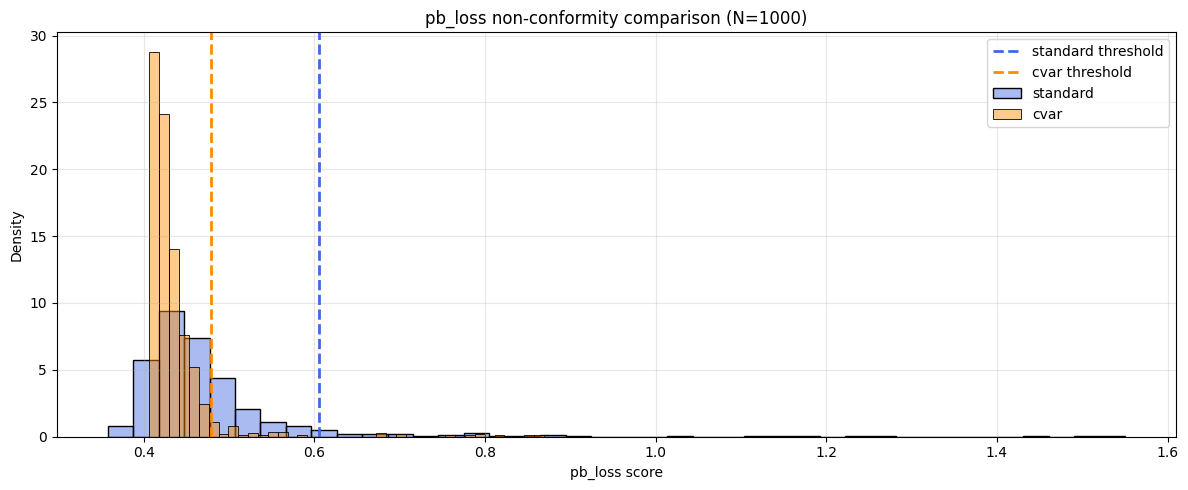

In [11]:
# Plot comparison
conformal_pipeline.plot_verification_comparison(result)